# A First Empirical Exploration of Machine Learning Concepts

## Basics
In the following, we will lay out a few core definitions of Machine Learning concepts. We will then explore those concepts in simple cases.

### A Simple Regression Task

In this first exploration we will consider the *regression task* in which we are given a *training set* $S=\{(x_1,y_1),\ldots,(x_m,y_m)\}$ of *examples* $(x_i,y_i)$, where: 
+ $x_i \in {\cal X}$ is called the *input* or the *instance*, 
+ ${\cal X}$ is the *input domain*, 
+ $y_i\in{\cal Y}$ is called the *output*, the *target* or the *label* and 
+ ${\cal Y}$ the *label set*. 

Our strategy to solve the regression task is to *learn* a *model* $h:{\cal X}\rightarrow {\cal Y}$ or to "teach" a learner to come up with a prediction rule to predict the ouputs associated to the inputs. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
train = pd.read_csv("./simpledata_train.csv")
train.shape

(50, 2)

<Axes: xlabel='x', ylabel='y'>

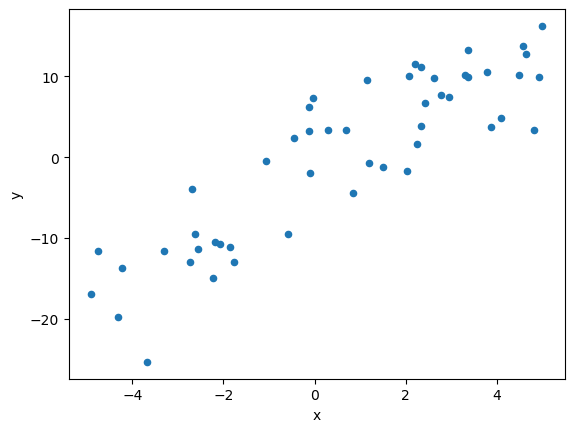

In [4]:
train.plot.scatter("x", "y")

### A Simple Regression Model
As a simple learner we will consider a **nearest neighbor regressor**. The nearest neighbor prediction rule is based on pooling the outputs of the nearest instances to take a decision. Given an instance $z\in{\cal X}$ the predicted output of a $k-$nearest neighbor regressor will be $$h(z)=\frac{1}{k}\sum_{i\in{N}_k(z, S)} y_i$$ where ${N}_k(z, S)$ is the set of the $k$ nearest instances in $S$ to $z$ according to a pre-specified distance.

In [5]:
from sklearn import neighbors
# #############################################################################
# Fit regression model
k = 2
X = train["x"].values[:,np.newaxis] # column matrix instead of line vector
y = train["y"]

knn = neighbors.KNeighborsRegressor(k)
knn.fit(X, y)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


To visualise the prediction rule lets compute the prediction for a range of points in the support of the instances:  

Text(0.5, 1.0, 'KNeighborsRegressor k = 2')

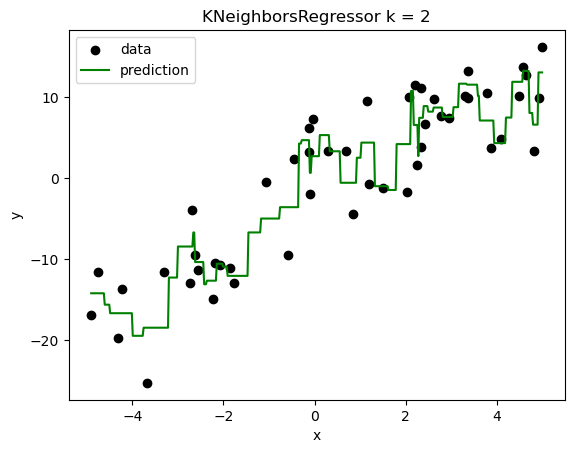

In [6]:
xsupport = pd.DataFrame(np.linspace(min(train.x),max(train.x),500))
y_ = knn.predict(xsupport) 

plt.scatter(train["x"], train["y"], c='k', label='data')
plt.plot(xsupport, y_, c='g', label='prediction')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("KNeighborsRegressor k = " + str(k))

### How good is the prediction?
To measure how good the prediction rule $h_S(x)=\hat{y}$ learned over training set $S$ is for an example $(x,y)$ we compute the *squared residual error* $(\hat{y}-y)^2$. To measure how good the prediction is on a set of examples we compute a *loss function* for example the *mean squared error (MSE)*. The training error is the loss function computed over the training set: $$l(S,h_S)=\frac{1}{m} \sum_{(x_i,y_i)\in S} (h_S(x_i)-y_i)^2 $$

In [7]:
from sklearn.metrics import mean_squared_error
yhat_train = knn.predict(X)
mean_squared_error(y, yhat_train)

12.366034124597014

The training examples where generated by an unknown distribution ${\cal D}$. Another measure of success is how good is our prediction rule on unseen examples generated by the same distribution ${\cal D}$. The *generalisation error* is the loss function computed on a *test* set $E$ sampled from distribution ${\cal D}$:
$$l(E,h_S)=\frac{1}{m_E} \sum_{(x_i, y_i)\in E} (h_S(x_i)-y_i)^2 $$

> ## Questions:
> 1. What is the input domain in the simple dataset?
> 1. Compute the generalisation error using `simpledata_test.csv`.
> 1. As a loss function we could also consider the [explained variance](https://scikit-learn.org/stable/modules/model_evaluation.html#explained-variance-score). How does it relate to MSE? Compute training and generalisation errors for this loss function.
> 1. How dependent is the prediction on the training set? Lets assume we can ask for another training set (see next section). Compute the training and generalisation error for this new training set. Repeat the experiment several times in order to get a mean and a variance.
> 1. How dependent is the prediction on the size of the training set? Draw a plot to visualise it.
> 1. How dependent is the prediction on the hyperparameter $k$? Draw a plot to visualise it.
> 1. Relate this experiment to the bias-variance decomposition of the true error.

## Unlimited sample simulation

<Axes: xlabel='x', ylabel='y'>

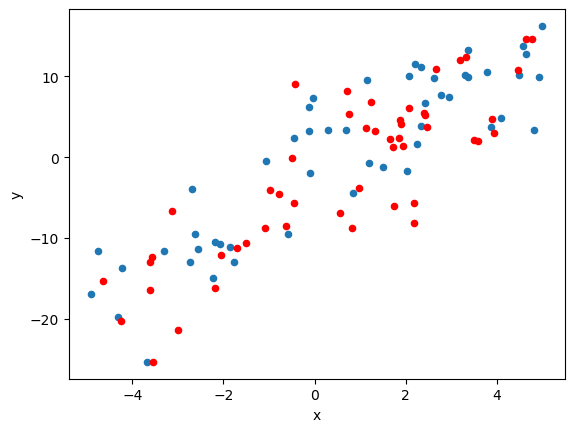

In [22]:
from unknown_distrib import data_sample
train2 = data_sample(50)

ax=train.plot(kind="scatter", x="x", y="y")
train2.plot(kind="scatter", x="x", y="y",ax=ax, color="red")

In [20]:
train2 = data_sample(50)
X = train2["x"].values[:,np.newaxis] # column matrix instead of line vector
y = train2["y"]

knn = neighbors.KNeighborsRegressor(k)
knn.fit(X, y)
yhat_train = knn.predict(X)
print(mean_squared_error(y, yhat_train))

test = data_sample(50)#pd.read_csv("./simpledata_test.csv")
X_test = test["x"].values[:,np.newaxis] # column matrix instead of line vector
y_test = test["y"]

yhat_test = knn.predict(X_test)
print(mean_squared_error(y_test, yhat_test))

10.443430404268204
43.60732160729985


## Question 1: 

In the simple dataset, the input domain will be ${\cal X}$

## Question 2:

In [30]:
X_train = train["x"].values[:,np.newaxis] # column matrix instead of line vector
y_train = train["y"]

knn = neighbors.KNeighborsRegressor(k)
knn.fit(X_train, y_train)
yhat_simple_train = knn.predict(X_train)

simpletest = pd.read_csv("./simpledata_test.csv")
X_simple_test = simpletest["x"].values[:,np.newaxis] # column matrix instead of line vector
y_simple_test = simpletest["y"]

yhat_simple_test = knn.predict(X_simple_test)
print(f"The generalisation error using the simple dataset test is {mean_squared_error(y_simple_test, yhat_simple_test)}")

The generalisation error using the simple dataset test is 35.03502108936177


## Question 3:

By using the Bias-Variance Decomposition, we know that Var($y-\hat{y}$) = MSE - (bias)²

In [32]:
from sklearn.metrics import explained_variance_score

print(f"The training error considering the explained variance function is {explained_variance_score(y_train, yhat_simple_train)}")

print(f"The generalisation error considering the explained variance function is {explained_variance_score(y_simple_test, yhat_simple_test)}")

The training error considering the explained variance function is 0.881886364478834
The generalisation error considering the explained variance function is 0.6049437715095964


## Question 4:

The prediction is very sensitive to training set. Indeed, whether we change the training set, the k nearest neighbors may change especially if k is small, therefore the prediction will change too.

In [41]:
# I used the explained variance as loss function to get a score which will be more interesting to compare 

n = 25

# Stock all explained_variance_score
training_err = []
generalisation_err = []

for i in range(n):
    train_i = data_sample(50)
    X_i = train_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_i = train_i["y"]

    knn = neighbors.KNeighborsRegressor(k)
    knn.fit(X_i, y_i)
    yhat_train = knn.predict(X_i)

    test_i = data_sample(50)
    X_test_i = test_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_test_i = test_i["y"]

    yhat_test_i = knn.predict(X_test_i)

    training_err.append(explained_variance_score(y_i,yhat_train))

    generalisation_err.append(explained_variance_score(y_test_i,yhat_test_i))

print(f"The mean of the training error on {n} experiments is {np.mean(training_err)} ")

print(f"The mean of the generalisation error on {n} experiments is {np.mean(generalisation_err)} ")

print(f"The variance of the training error on {n} experiments is {np.var(training_err)} ")

print(f"The variance of the generalisation error on {n} experiments is {np.var(generalisation_err)} ")

The mean of the training error on 25 experiments is 0.8927650356258715 
The mean of the generalisation error on 25 experiments is 0.6860232010569992 
The variance of the training error on 25 experiments is 0.0007474953552706362 
The variance of the generalisation error on 25 experiments is 0.006214809655319756 


## Question 5:

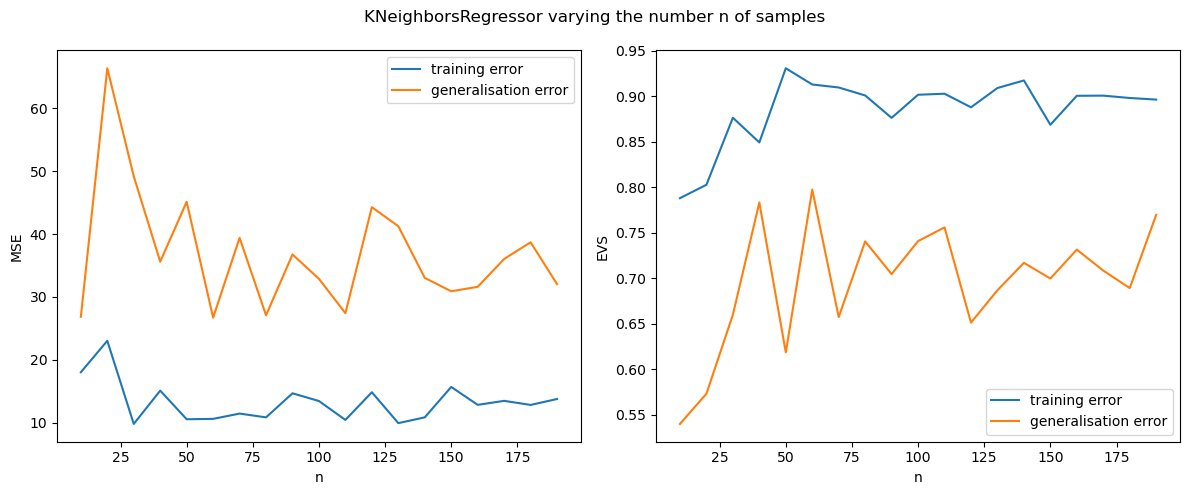

In [79]:
sizes = np.arange(10,200,10)
k = 2

# Stock all MSE and explained_variance_score
training_err_mean = []
generalisation_err_mean = []

training_err_var = []
generalisation_err_var = []

for n in sizes:
    train_i = data_sample(n)
    X_i = train_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_i = train_i["y"]

    knn = neighbors.KNeighborsRegressor(k)
    knn.fit(X_i, y_i)
    yhat_train = knn.predict(X_i)

    test_i = data_sample(n)
    X_test_i = test_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_test_i = test_i["y"]

    yhat_test_i = knn.predict(X_test_i)

    training_err_mean.append(mean_squared_error(y_i,yhat_train))
    generalisation_err_mean.append(mean_squared_error(y_test_i,yhat_test_i))
    
    training_err_var.append(explained_variance_score(y_i,yhat_train))

    generalisation_err_var.append(explained_variance_score(y_test_i,yhat_test_i))

fig, axs = plt.subplots(1, 2, figsize=(12,5))

#Show the graph considering the MSE
axs[0].plot(sizes,training_err_mean, label="training error")
axs[0].plot(sizes,generalisation_err_mean, label="generalisation error")
axs[0].set_xlabel("n")
axs[0].set_ylabel("MSE")
axs[0].legend()


#Show the graph considering the EVS
axs[1].plot(sizes,training_err_var, label="training error")
axs[1].plot(sizes,generalisation_err_var, label="generalisation error")
axs[1].set_xlabel("n")
axs[1].set_ylabel("EVS")
axs[1].legend()

fig.suptitle("KNeighborsRegressor varying the number n of samples")
plt.tight_layout()
plt.show()

# Answer : 

As we can see, if we increase the number of samples in the data set, the MSE and the EVS stabilize after a certain value of sample which is 75. Before this value, the EVS is low and the MSE is high which not all optimal, so should have a minimum number of value to train model.

## Question 6:

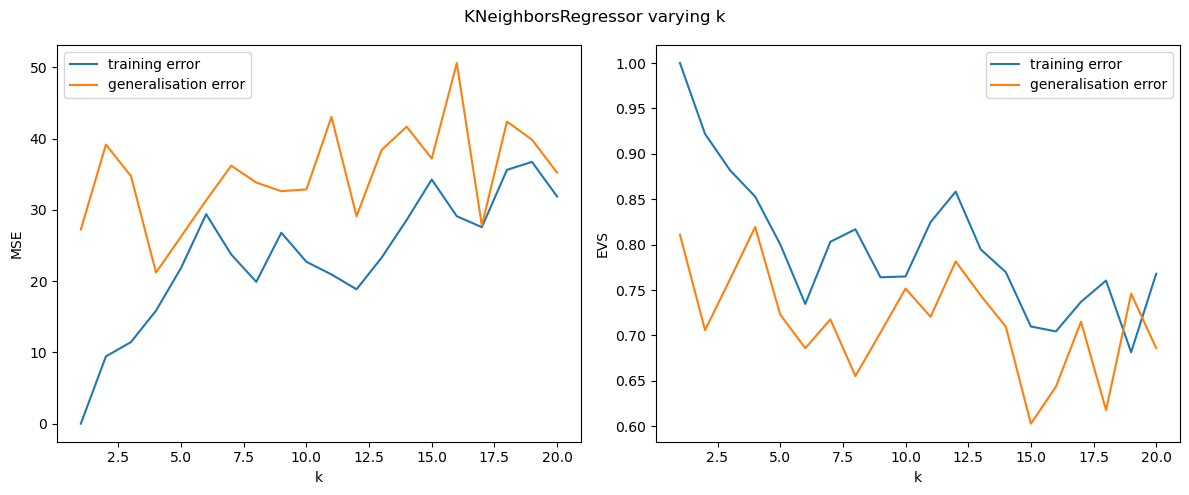

In [81]:
k = np.arange(1,21)

# Stock all explained_variance_score
training_err_mean = []
generalisation_err_mean = []

training_err_var = []
generalisation_err_var = []

for i in k:
    train_i = data_sample(50)
    X_i = train_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_i = train_i["y"]

    knn = neighbors.KNeighborsRegressor(i)
    knn.fit(X_i, y_i)
    yhat_train = knn.predict(X_i)

    test_i = data_sample(50)
    X_test_i = test_i["x"].values[:,np.newaxis] # column matrix instead of line vector
    y_test_i = test_i["y"]

    yhat_test_i = knn.predict(X_test_i)

    training_err_mean.append(mean_squared_error(y_i,yhat_train))
    generalisation_err_mean.append(mean_squared_error(y_test_i,yhat_test_i))
    
    training_err_var.append(explained_variance_score(y_i,yhat_train))

    generalisation_err_var.append(explained_variance_score(y_test_i,yhat_test_i))

fig, axs = plt.subplots(1, 2, figsize=(12,5))

#Show the graph considering the MSE
axs[0].plot(k,training_err_mean, label="training error")
axs[0].plot(k,generalisation_err_mean, label="generalisation error")
axs[0].set_xlabel("k")
axs[0].set_ylabel("MSE")
axs[0].legend()


#Show the graph considering the EVS
axs[1].plot(k,training_err_var, label="training error")
axs[1].plot(k,generalisation_err_var, label="generalisation error")
axs[1].set_xlabel("k")
axs[1].set_ylabel("EVS")
axs[1].legend()

fig.suptitle("KNeighborsRegressor varying k")
plt.tight_layout()
plt.show()

# Answer :

If k is small, the prediction becomes very sensitive to changes. Indeed, the nearest neighbor will vary easily if we have k = 1 for instance. However, with a large k, the prediction becomes more stable to changes despite that more we increase k, more we get a high bias as we saw on the graphs above.

## Question 7:

The bias-variance decomposition of the true error can be written as :  MSE = Variance + (bias)² where MSE is the true error. \
If k is small we get a low bias, nevertheless we obtain a high variance which means that the training error is low but the test error fluctuates a lot. It is due to overfitting. \
If k is large, we obtain a lower variance but the bias rises which means that the test error becomes more stable but the training error increases.\
To find an optimal k, we need to minimize Variance + (bias)² which is the bias–variance trade-off.

In our example, the optimal k seems to be around 7.




